In [1]:
# Import libraries and set seed
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
np.random.seed(8)

## Read & Clean Data


In [2]:
# Read data 
menstrual = pd.read_csv('data.csv')
menstrual = menstrual.drop(columns = 'id')
menstrual.head()

,day_in_study,sedentary_mins,active_mins,glucose_mean,rhr_mean,minutes_asleep,minutes_awake,sleep_efficiency_mean,sleep_score_overall,sleep_score_revitalization,...,headaches,cramps,sorebreasts,fatigue,sleepissue,moodswing,stress,foodcravings,indigestion,bloating
0,1,753.0,64,5.498958,74.785346,1027.0,26.0,98.0,NaN,NaN,...,High,Very Low/Little,Very Low/Little,High,Low,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
1,2,855.0,74,5.372222,80.407307,77.0,4.0,95.0,NaN,NaN,...,Very High,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
2,3,751.0,159,5.579514,84.686869,502.0,28.0,95.0,NaN,NaN,...,High,Very Low/Little,Very Low/Little,Very High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
3,4,905.0,86,5.206597,83.852219,384.0,65.0,93.0,80.0,22.0,...,Very Low/Little,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
4,5,1430.0,10,5.381597,0.000000,NaN,NaN,NaN,NaN,NaN,...,Very Low/Little,Very Low/Little,Very Low/Little,High,High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little


In [3]:
mlp_data = menstrual[['day_in_study', 'active_mins', 'glucose_mean', 'rhr_mean', 'sleep_score_overall', 'phase', 'lh', 'estrogen', 'sleep_efficiency_mean', 'headaches', 'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion', 'bloating']]
mlp_data.head()

,day_in_study,active_mins,glucose_mean,rhr_mean,sleep_score_overall,phase,lh,estrogen,sleep_efficiency_mean,headaches,cramps,sorebreasts,fatigue,sleepissue,moodswing,stress,foodcravings,indigestion,bloating
0,1,64,5.498958,74.785346,NaN,Follicular,2.9,94.2,98.0,High,Very Low/Little,Very Low/Little,High,Low,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
1,2,74,5.372222,80.407307,NaN,Follicular,1.2,226.3,95.0,Very High,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
2,3,159,5.579514,84.686869,NaN,Follicular,3.5,276.8,95.0,High,Very Low/Little,Very Low/Little,Very High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
3,4,86,5.206597,83.852219,80.0,Fertility,1.8,322.1,93.0,Very Low/Little,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
4,5,10,5.381597,0.000000,NaN,Fertility,4.6,244.9,NaN,Very Low/Little,Very Low/Little,Very Low/Little,High,High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little


In [4]:
targets = ['headaches', 'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion', 'bloating']
mlp_bin = mlp_data.copy()
for col in targets:
    mlp_bin[f'bin_{col}'] = (mlp_data[col] != 'Not at all').astype(int)

mlp_bin = mlp_bin.drop(columns=targets)
mlp_bin.head()

,day_in_study,active_mins,glucose_mean,rhr_mean,sleep_score_overall,phase,lh,estrogen,sleep_efficiency_mean,bin_headaches,bin_cramps,bin_sorebreasts,bin_fatigue,bin_sleepissue,bin_moodswing,bin_stress,bin_foodcravings,bin_indigestion,bin_bloating
0,1,64,5.498958,74.785346,NaN,Follicular,2.9,94.2,98.0,1,1,1,1,1,1,1,1,1,1
1,2,74,5.372222,80.407307,NaN,Follicular,1.2,226.3,95.0,1,1,1,1,1,1,1,1,1,1
2,3,159,5.579514,84.686869,NaN,Follicular,3.5,276.8,95.0,1,1,1,1,1,1,1,1,1,1
3,4,86,5.206597,83.852219,80.0,Fertility,1.8,322.1,93.0,1,1,1,1,1,1,1,1,1,1
4,5,10,5.381597,0.000000,NaN,Fertility,4.6,244.9,NaN,1,1,1,1,1,1,1,1,1,1


In [5]:
mlp_onehot = pd.get_dummies(mlp_bin, drop_first = True, dtype = int)
mlp_onehot.head()

,day_in_study,active_mins,glucose_mean,rhr_mean,sleep_score_overall,lh,estrogen,sleep_efficiency_mean,bin_headaches,bin_cramps,...,bin_fatigue,bin_sleepissue,bin_moodswing,bin_stress,bin_foodcravings,bin_indigestion,bin_bloating,phase_Follicular,phase_Luteal,phase_Menstrual
0,1,64,5.498958,74.785346,NaN,2.9,94.2,98.0,1,1,...,1,1,1,1,1,1,1,1,0,0
1,2,74,5.372222,80.407307,NaN,1.2,226.3,95.0,1,1,...,1,1,1,1,1,1,1,1,0,0
2,3,159,5.579514,84.686869,NaN,3.5,276.8,95.0,1,1,...,1,1,1,1,1,1,1,1,0,0
3,4,86,5.206597,83.852219,80.0,1.8,322.1,93.0,1,1,...,1,1,1,1,1,1,1,0,0,0
4,5,10,5.381597,0.000000,NaN,4.6,244.9,NaN,1,1,...,1,1,1,1,1,1,1,0,0,0


In [6]:
print(mlp_onehot.isna().sum())

day_in_study               0
active_mins                0
glucose_mean             590
rhr_mean                   0
sleep_score_overall      450
lh                       223
estrogen                 224
sleep_efficiency_mean    526
bin_headaches              0
bin_cramps                 0
bin_sorebreasts            0
bin_fatigue                0
bin_sleepissue             0
bin_moodswing              0
bin_stress                 0
bin_foodcravings           0
bin_indigestion            0
bin_bloating               0
phase_Follicular           0
phase_Luteal               0
phase_Menstrual            0
dtype: int64


In [7]:
# Impute missing features with mean
mlp_onehot['glucose_mean'] = mlp_onehot['glucose_mean'].fillna(mlp_onehot['glucose_mean'].mean())
mlp_onehot['sleep_score_overall'] = mlp_onehot['sleep_score_overall'].fillna(mlp_onehot['glucose_mean'].mean())
mlp_onehot['lh'] = mlp_onehot['lh'].fillna(mlp_onehot['lh'].mean())
mlp_onehot['estrogen'] = mlp_onehot['estrogen'].fillna(mlp_onehot['estrogen'].mean())
mlp_onehot['sleep_efficiency_mean'] = mlp_onehot['sleep_efficiency_mean'].fillna(mlp_onehot['sleep_efficiency_mean'].mean())

print(mlp_onehot.isna().sum())

day_in_study             0
active_mins              0
glucose_mean             0
rhr_mean                 0
sleep_score_overall      0
lh                       0
estrogen                 0
sleep_efficiency_mean    0
bin_headaches            0
bin_cramps               0
bin_sorebreasts          0
bin_fatigue              0
bin_sleepissue           0
bin_moodswing            0
bin_stress               0
bin_foodcravings         0
bin_indigestion          0
bin_bloating             0
phase_Follicular         0
phase_Luteal             0
phase_Menstrual          0
dtype: int64


In [8]:
target_cols = [col for col in mlp_onehot.columns if 'bin' in col]
for col in target_cols:
    mlp_onehot[col] = mlp_onehot.pop(col)

mlp_onehot.head()

,day_in_study,active_mins,glucose_mean,rhr_mean,sleep_score_overall,lh,estrogen,sleep_efficiency_mean,phase_Follicular,phase_Luteal,...,bin_headaches,bin_cramps,bin_sorebreasts,bin_fatigue,bin_sleepissue,bin_moodswing,bin_stress,bin_foodcravings,bin_indigestion,bin_bloating
0,1,64,5.498958,74.785346,11.406948,2.9,94.2,98.000000,1,0,...,1,1,1,1,1,1,1,1,1,1
1,2,74,5.372222,80.407307,11.406948,1.2,226.3,95.000000,1,0,...,1,1,1,1,1,1,1,1,1,1
2,3,159,5.579514,84.686869,11.406948,3.5,276.8,95.000000,1,0,...,1,1,1,1,1,1,1,1,1,1
3,4,86,5.206597,83.852219,80.000000,1.8,322.1,93.000000,0,0,...,1,1,1,1,1,1,1,1,1,1
4,5,10,5.381597,0.000000,11.406948,4.6,244.9,92.455916,0,0,...,1,1,1,1,1,1,1,1,1,1


## Prep Data for MLP


In [9]:
mlp_array = mlp_onehot.to_numpy()
print(mlp_array)

[[  1.          64.           5.49895833 ...   1.           1.
    1.        ]
 [  2.          74.           5.37222222 ...   1.           1.
    1.        ]
 [  3.         159.           5.57951389 ...   1.           1.
    1.        ]
 ...
 [ 88.         181.           7.15138889 ...   1.           1.
    1.        ]
 [ 89.         267.           7.11875    ...   1.           1.
    1.        ]
 [ 90.         331.          11.40694841 ...   1.           1.
    1.        ]]


In [10]:
X = mlp_array[:, :-10]   # features
y = mlp_array[:, -10:]   # 10 binary outputs

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3698, 11)
y shape: (3698, 10)


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X).round(2)

print("X_scaled shape:", X_scaled.shape)
print("y shape:", y.shape)

X_scaled shape: (3698, 11)
y shape: (3698, 10)


In [12]:
ones = np.ones((X_scaled.shape[0], 1))
Phi = np.hstack((X_scaled, ones))

print("Phi shape:", Phi.shape)

Phi shape: (3698, 12)


In [13]:
Phi_train, Phi_test, y_train, y_test = train_test_split(
    Phi, y, test_size=0.3, random_state=42
)

print("Phi_train:", Phi_train.shape)
print("Phi_test:", Phi_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Phi_train: (2588, 12)
Phi_test: (1110, 12)
y_train: (2588, 10)
y_test: (1110, 10)


In [14]:
# Inspect training set
Phi_train, y_train

(array([[0.24, 0.25, 0.02, ..., 0.  , 1.  , 1.  ],
        [0.81, 0.29, 0.02, ..., 0.  , 1.  , 1.  ],
        [0.69, 0.2 , 0.02, ..., 1.  , 0.  , 1.  ],
        ...,
        [0.56, 0.  , 0.61, ..., 0.  , 0.  , 1.  ],
        [0.3 , 0.23, 0.06, ..., 0.  , 0.  , 1.  ],
        [0.61, 0.33, 0.06, ..., 0.  , 1.  , 1.  ]]),
 array([[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [0., 0., 0., ..., 1., 1., 0.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]]))

## Implement MLP From Scratch Using Gradient Descent


In [15]:
# Define step size (eta), epochs, number of hidden nodes (q), W1, W2
eta = 0.1
epochs = 500

q = 8
d = Phi_train.shape[1]     # number of input columns including bias
k = y_train.shape[1]       # should be 10

np.random.seed(42)
W1 = np.random.randn(d, q) * 0.1
W2 = np.random.randn(q, k) * 0.1

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)

W1 shape: (12, 8)
W2 shape: (8, 10)


In [16]:
# Define f(x) using ReLU for h and sigmoid for output
def f(x):
    h = np.maximum(0, W1.T @ x)
    return 1 / (1 + np.exp(-1 * (W2.T @ h)))

In [17]:
# Run Gradient Descent
errors = []
n = Phi_train.shape[0]

for epoch in range(epochs):
    # calculate dW2
    dW2 = 0
    for i, j in enumerate(y_train):
        x = np.reshape(Phi_train[i], (d, 1))
        h = np.maximum(0, W1.T @ x)
        yhat = 1 / (1 + np.exp(-1 * (W2.T @ h)))          # (k,1)
        error = yhat - y_train[i].reshape(-1, 1)          # (k,1)

        dW2 += (1 / n) * (h @ error.T)                    # (q,k)

    # calculate dW1
    dW1 = 0
    for i, j in enumerate(y_train):
        x = np.reshape(Phi_train[i], (d, 1))
        h = np.maximum(0, W1.T @ x)
        yhat = 1 / (1 + np.exp(-1 * (W2.T @ h)))          # (k,1)
        error = yhat - y_train[i].reshape(-1, 1)          # (k,1)

        mat1 = np.heaviside(h, 0)                         # (q,1)
        hidden_error = (W2 @ error) * mat1               # (q,1)

        dW1 += (1 / n) * (x @ hidden_error.T)            # (d,q)

    # update W1 & W2
    W1 = W1 - eta * dW1
    W2 = W2 - eta * dW2

    # calculate f(x) at each training value and error (log loss)
    f_x = []
    for i, j in enumerate(Phi_train):
        x = np.reshape(Phi_train[i], (d, 1))
        h = np.maximum(0, W1.T @ x)
        yhat = 1 / (1 + np.exp(-1 * (W2.T @ h)))
        f_x.append(yhat.flatten())

    f_x = np.array(f_x)   # shape (n, k)

    eps = 1e-8
    e = -(1 / n) * np.sum(
        y_train * np.log(f_x + eps) +
        (1 - y_train) * np.log(1 - f_x + eps)
    )
    errors.append(e)

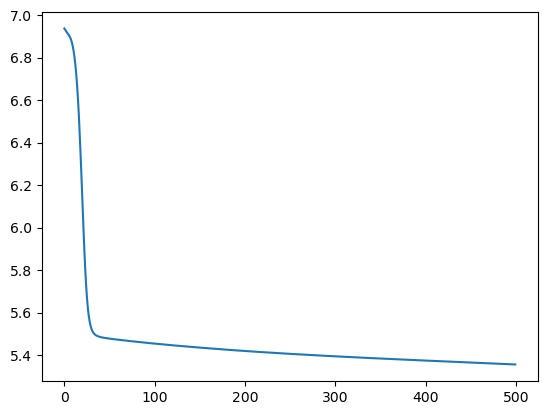

In [18]:
# Plot convergence
import matplotlib.pyplot as plt
plt.plot(range(epochs), errors, label='line')
plt.show()

In [19]:
# Print final estimates of W1 and W2
print('W1:\n', W1)
print('W2:\n', W2)

W1:
 [[ 4.72680746e-02 -7.73006934e-02  5.08921061e-02  1.45102611e-01
  -2.70914776e-02 -2.34136957e-02  2.30670708e-01  5.93368771e-02]
 [-4.61437816e-02 -3.16523825e-01 -8.59780659e-01 -8.94386593e-02
   2.32600709e-02 -1.91328024e-01 -2.88486198e-01 -6.93560566e-02]
 [-1.01460996e-01  1.06536386e-01 -2.40336454e-02 -1.30116601e-01
   1.43094289e-01 -2.25776300e-02  1.80324064e-02 -1.42936956e-01]
 [-5.44382725e-02  4.95660045e-02 -2.52255272e-03 -3.83123686e-02
  -5.93341708e-02 -2.91693750e-02 -1.01089116e-01  1.56657147e-01]
 [-1.15067727e-03 -2.97743093e-01 -2.85064359e-01 -2.30105671e-01
   1.70247922e-02 -1.95967012e-01 -2.48368220e-01 -1.77157859e-02]
 [ 7.30726503e-02  4.00947336e-02  2.37768327e-03 -2.79982147e-02
  -1.47875713e-01 -7.19844208e-02 -3.30941169e-02  1.04697693e-01]
 [ 3.51757849e-02 -2.49665953e-01 -1.42047276e-01 -5.55164998e-02
  -6.83796728e-02  6.11676289e-02  5.84412777e-02  8.57412363e-02]
 [-8.63629087e-02  7.48316929e-01  1.48918200e+00  5.32068613e-0

In [34]:
# Predict using test data
y_pred = []
for i, j in enumerate(Phi_test):
    x = np.reshape(Phi_test[i], (d, 1))
    y_pred.append(f(x).flatten())

y_pred = np.array(y_pred)

print(y_pred.shape)
print(y_pred[754])

(1110, 10)
[0.69573167 0.58305174 0.55006491 0.86298025 0.81403283 0.71633088
 0.85384548 0.75201017 0.67262205 0.69469833]


In [30]:
# Evaluate accuracy of algorithm using log loss and accuracy
n_test = Phi_test.shape[0]
y_pred = np.array(y_pred).reshape(n_test, 10)

eps = 1e-8
log_loss = -(1 / n_test) * np.sum(
    (y_test * np.log(y_pred + eps)) + ((1 - y_test) * np.log(1 - y_pred + eps))
)

y_pred_binary = np.round(y_pred)
matches = 0

for i in range(y_pred_binary.shape[0]):
    for j in range(y_pred_binary.shape[1]):
        if y_pred_binary[i, j] == y_test[i, j]:
            matches += 1

accuracy = matches / (y_pred_binary.shape[0] * y_pred_binary.shape[1])

print('Log Loss:', log_loss)
print('Accuracy:', accuracy)

Log Loss: 5.616362100938008
Accuracy: 0.7096396396396396
